#  Water Pump Status Prediction using CatBoost



### Machine Learning | Multiclass Classification | Python

##  Business Problem

Water pumps are critical infrastructure in rural Tanzania.

The objective is to predict whether a pump is functional, requires repair, or is non-functional in order to help prioritize maintenance activities.

##  Setup

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42


## Data Loading

The project uses separate files for training features, training labels and test features. All files should be stored in the `data/` directory.


In [3]:

train_values = pd.read_csv("4910797b-ee55-40a7-8668-10efd5c1b960 (1).csv")
train_labels = pd.read_csv("0bf8bc6e-30d0-4c50-956a-603fc693d966 (1).csv")
test_values = pd.read_csv("702ddfc5-68cd-4d1d-a0de-f5f566f76d91.csv")

print("train_values:", train_values.shape)
print("train_labels:", train_labels.shape)
print("test_values:", test_values.shape)

train_values: (59400, 40)
train_labels: (59400, 2)
test_values: (14850, 40)


##  Data Integration

In [4]:
train = train_values.merge(
    train_labels,
    on="id",
    how="inner",
    validate="one_to_one"
)

assert len(train) == len(train_values)
assert train["id"].is_unique

display(train.head(3))

print(f"Combined training data: {train.shape}")

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional


Combined training data: (59400, 41)


## Exploratory Data Analysis

,status_group,count,percentage
0,functional,32259,54.308081
1,non functional,22824,38.424242
2,functional needs repair,4317,7.267677


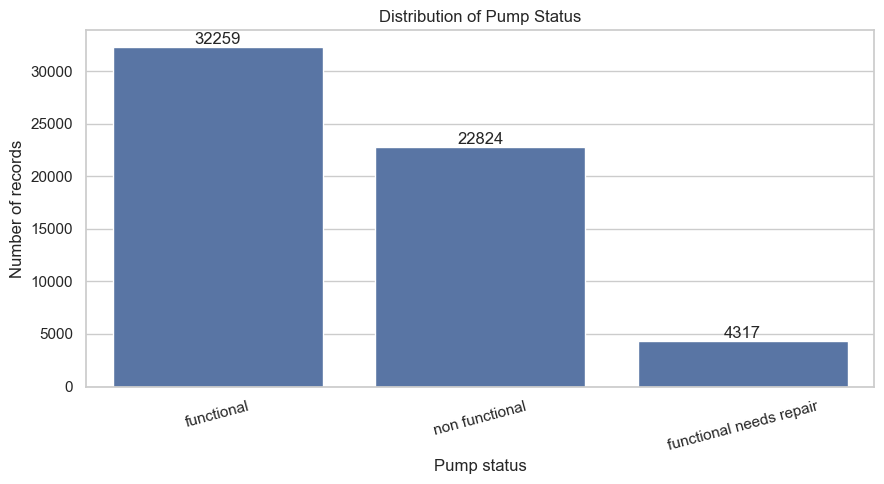

In [5]:
target_distribution = (
    train["status_group"]
    .value_counts()
    .rename_axis("status_group")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"]
    / len(train)
    * 100
)

display(target_distribution)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=target_distribution,
    x="status_group",
    y="count"
)

ax.bar_label(ax.containers[0])

plt.title("Distribution of Pump Status")
plt.xlabel("Pump status")
plt.ylabel("Number of records")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

The target is imbalanced, particularly for `functional needs repair`. For this reason, model performance will be evaluated with class-level metrics in addition to overall accuracy.

In [6]:
missing_summary = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percentage": train.isna().mean() * 100
})

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

display(missing_summary.head(15))

,missing_count,missing_percentage
scheme_name,28810,48.501684
scheme_management,3878,6.528620
installer,3655,6.153199
funder,3637,6.122896
public_meeting,3334,5.612795
permit,3056,5.144781
subvillage,371,0.624579
wpt_name,2,0.003367


In [7]:
zero_check_columns = [
    "construction_year",
    "population",
    "longitude",
    "latitude",
    "gps_height"
]

zero_summary = pd.DataFrame({
    "zero_count": [
        (train[column] == 0).sum()
        for column in zero_check_columns
    ],
    "zero_percentage": [
        (train[column] == 0).mean() * 100
        for column in zero_check_columns
    ]
}, index=zero_check_columns)

display(
    zero_summary.sort_values(
        "zero_percentage",
        ascending=False
    )
)

,zero_count,zero_percentage
population,21381,35.994949
construction_year,20709,34.863636
gps_height,20438,34.407407
longitude,1812,3.050505
latitude,0,0.000000


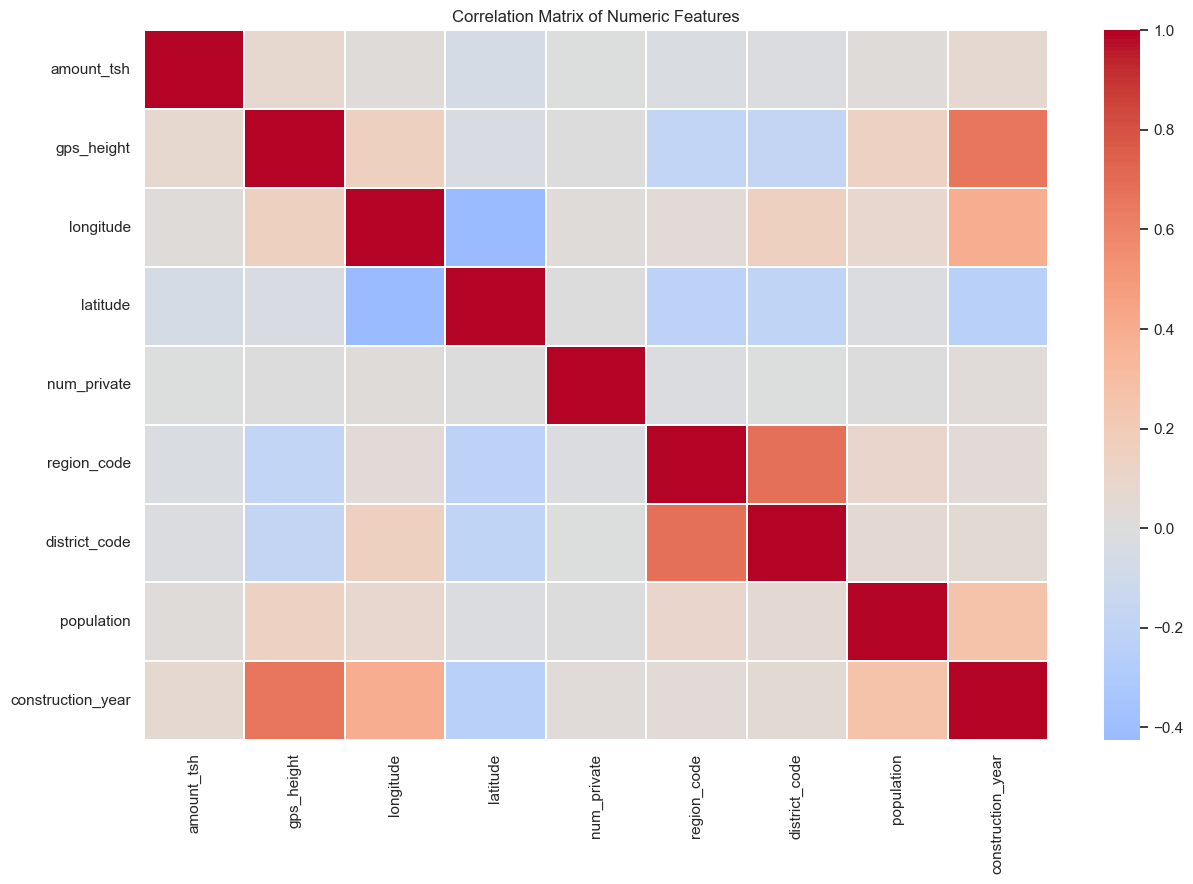

In [8]:
numeric_columns = (
    train
    .select_dtypes(include=np.number)
    .columns
    .drop("id", errors="ignore")
)

correlation_matrix = train[numeric_columns].corr()

plt.figure(figsize=(13, 9))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

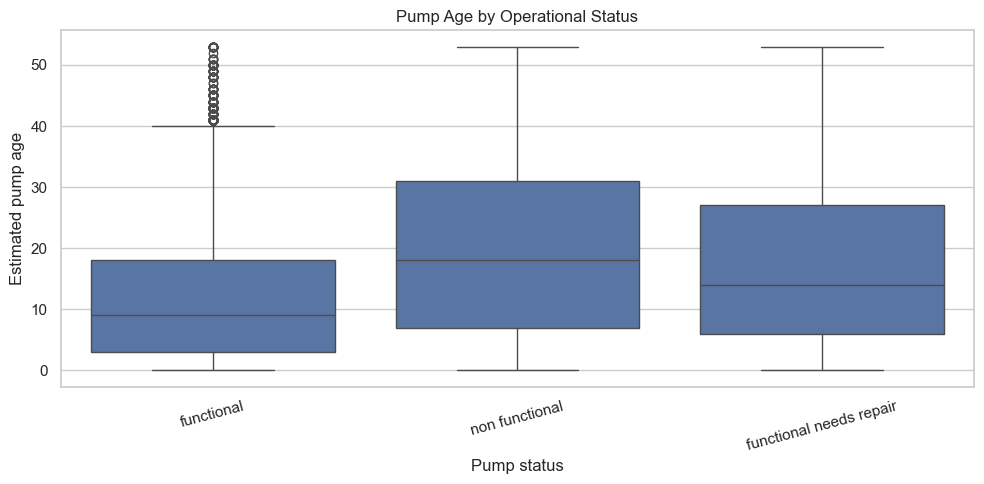

In [9]:
eda_data = train.copy()

eda_data["date_recorded"] = pd.to_datetime(
    eda_data["date_recorded"],
    errors="coerce"
)

eda_data["construction_year_clean"] = (
    eda_data["construction_year"]
    .replace(0, np.nan)
)

eda_data["pump_age"] = (
    eda_data["date_recorded"].dt.year
    - eda_data["construction_year_clean"]
)

eda_data.loc[
    (eda_data["pump_age"] < 0)
    | (eda_data["pump_age"] > 100),
    "pump_age"
] = np.nan

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=eda_data,
    x="status_group",
    y="pump_age"
)

plt.title("Pump Age by Operational Status")
plt.xlabel("Pump status")
plt.ylabel("Estimated pump age")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

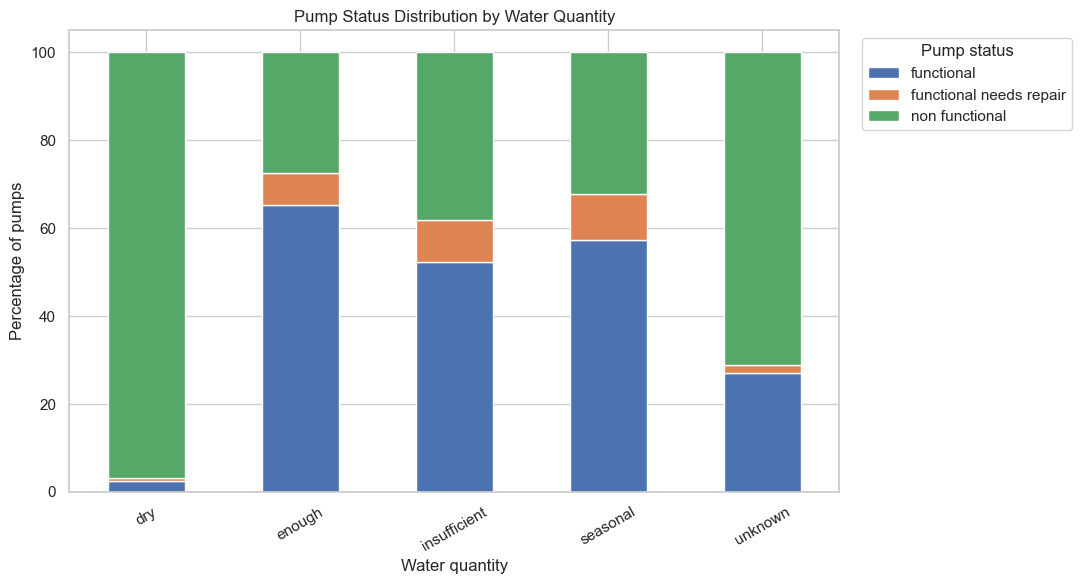

In [10]:
quantity_status = pd.crosstab(
    train["quantity"],
    train["status_group"],
    normalize="index"
).mul(100)

quantity_status.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Pump Status Distribution by Water Quantity")
plt.xlabel("Water quantity")
plt.ylabel("Percentage of pumps")
plt.legend(
    title="Pump status",
    bbox_to_anchor=(1.02, 1)
)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

##  Feature Engineering

The main transformation was the creation of `pump_age`, which provides a more meaningful representation of asset age than the raw construction year. Values of `construction_year = 0` were treated as missing information.

In [11]:
def prepare_features(df):
    df = df.copy()

    df["date_recorded"] = pd.to_datetime(
        df["date_recorded"],
        errors="coerce"
    )

    df["year_recorded"] = df["date_recorded"].dt.year
    df["month_recorded"] = df["date_recorded"].dt.month
    df["day_of_week_recorded"] = df["date_recorded"].dt.dayofweek

    df["construction_year"] = df["construction_year"].replace(0, np.nan)

    df["pump_age"] = df["year_recorded"] - df["construction_year"]

    invalid_age = (df["pump_age"] < 0) | (df["pump_age"] > 100)
    df.loc[invalid_age, "pump_age"] = np.nan

    categorical_columns = df.select_dtypes(
        include=["object", "bool"]
    ).columns

    for column in categorical_columns:
        df[column] = (
            df[column]
            .fillna("missing")
            .astype(str)
            .str.strip()
            .str.lower()
            .replace({
                "": "missing",
                "none": "missing",
                "nan": "missing",
                "unknown": "missing"
            })
        )

    columns_to_drop = [
        "id",
        "recorded_by",
        "date_recorded"
    ]

    return df.drop(
        columns=[
            column
            for column in columns_to_drop
            if column in df.columns
        ]
    )

## Modeling Dataset

In [12]:
X = prepare_features(
    train.drop(columns="status_group")
)

y = train["status_group"].copy()

X_test = prepare_features(test_values)

assert list(X.columns) == list(X_test.columns)

print(f"Training features: {X.shape}")
print(f"Target:            {y.shape}")
print(f"Test features:     {X_test.shape}")

Training features: (59400, 41)
Target:            (59400,)
Test features:     (14850, 41)


##  Validation Strategy

A stratified 80/20 split preserves the original class distribution in both training and validation sets.

In [13]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train = X_train.copy()
X_valid = X_valid.copy()
X_test = X_test.copy()

categorical_features = (
    X_train
    .select_dtypes(include=["object", "bool"])
    .columns
    .tolist()
)

for column in categorical_features:
    X_train[column] = X_train[column].astype(str)
    X_valid[column] = X_valid[column].astype(str)
    X_test[column] = X_test[column].astype(str)

categorical_feature_indices = [
    X_train.columns.get_loc(column)
    for column in categorical_features
]

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_valid.shape}")
print(f"Categorical features: {len(categorical_features)}")

Training set: (47520, 41)
Validation set: (11880, 41)
Categorical features: 28


##  Model Development

CatBoost was selected because it handles categorical variables natively and performs well on heterogeneous tabular datasets.

In [14]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False
)

In [ ]:
model.fit(
    X_train,
    y_train,
    cat_features=categorical_feature_indices,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=100
) 

0:	learn: 0.6930332	test: 0.6994441	best: 0.6994441 (0)	total: 1.09s	remaining: 18m 8s
100:	learn: 0.7753117	test: 0.7831959	best: 0.7836539 (99)	total: 1m 28s	remaining: 13m 5s


## Model Evaluation

Because the target is imbalanced, overall accuracy is complemented with balanced accuracy, macro F1-score, and class-level recall.

In [ ]:
y_pred = model.predict(
    X_valid
).flatten()

metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1-score",
        "Weighted F1-score"
    ],
    "value": [
        accuracy_score(
            y_valid,
            y_pred
        ),
        balanced_accuracy_score(
            y_valid,
            y_pred
        ),
        f1_score(
            y_valid,
            y_pred,
            average="macro"
        ),
        f1_score(
            y_valid,
            y_pred,
            average="weighted"
        )
    ]
})

display(
    metrics.style.format({
        "value": "{:.4f}"
    })
)

print(
    classification_report(
        y_valid,
        y_pred,
        digits=4,
        zero_division=0
    )
)

,metric,value
0,Accuracy,0.8126
1,Balanced accuracy,0.6553
2,Macro F1-score,0.6831
3,Weighted F1-score,0.8027


                         precision    recall  f1-score   support

             functional     0.7992    0.9124    0.8521      6452
functional needs repair     0.6090    0.2816    0.3851       863
         non functional     0.8564    0.7720    0.8120      4565

               accuracy                         0.8126     11880
              macro avg     0.7549    0.6553    0.6831     11880
           weighted avg     0.8074    0.8126    0.8027     11880



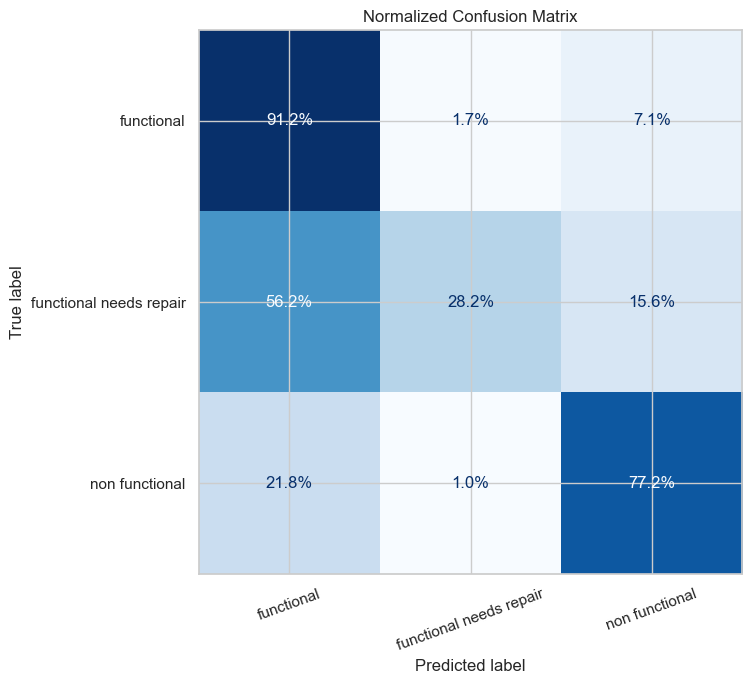

In [ ]:
class_names = model.classes_

cm = confusion_matrix(
    y_valid,
    y_pred,
    labels=class_names,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(
    ax=ax,
    cmap="Blues",
    values_format=".1%",
    colorbar=False
)

plt.title("Normalized Confusion Matrix")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

The model performs best on the **functional** class, with a recall of **91.2%**. The `functional needs repair` class is the most challenging, with a recall of only **28.2%**, and is frequently misclassified as `functional`.

## Feature Importance

,feature,importance
14,ward,9.294541
13,lga,8.692490
31,quantity_group,5.997485
30,quantity,4.812149
1,funder,4.718603
21,extraction_type,4.106073
18,scheme_name,3.840055
15,population,3.191397
35,waterpoint_type,3.043472
3,installer,3.033865


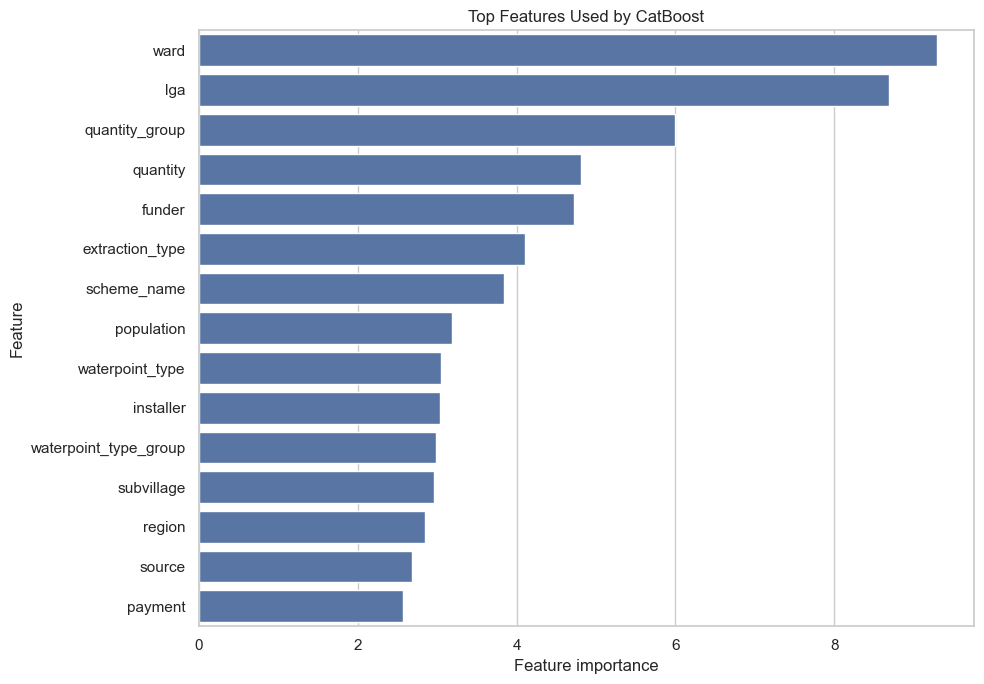

In [ ]:
feature_importance = (
    pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.get_feature_importance()
    })
    .sort_values(
        "importance",
        ascending=False
    )
)

top_features = feature_importance.head(15)

display(top_features)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top Features Used by CatBoost")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The most influential variables are `quantity`, `funder`, and `extraction_type`, indicating that water availability, funding source, and extraction method provide the strongest predictive information. Feature importance reflects predictive contribution and should not be interpreted as causality.

##  Final Model

The model is retrained using all labeled records and the best iteration identified during validation.

In [ ]:
X_full = prepare_features(
    train.drop(columns="status_group")
)

y_full = train["status_group"].copy()

X_test_final = prepare_features(
    test_values
)

categorical_features_full = (
    X_full
    .select_dtypes(include=["object", "bool"])
    .columns
    .tolist()
)

for column in categorical_features_full:
    X_full[column] = (
        X_full[column].astype(str)
    )

    X_test_final[column] = (
        X_test_final[column].astype(str)
    )

categorical_feature_indices_full = [
    X_full.columns.get_loc(column)
    for column in categorical_features_full
]

best_iteration = model.get_best_iteration()

final_iterations = (
    best_iteration + 1
    if best_iteration is not None
    and best_iteration >= 0
    else 500
)

final_model = CatBoostClassifier(
    iterations=final_iterations,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    random_seed=RANDOM_STATE,
    verbose=100,
    allow_writing_files=False
)

final_model.fit(
    X_full,
    y_full,
    cat_features=categorical_feature_indices_full
)

0:	learn: 1.0558236	total: 681ms	remaining: 10m 33s
100:	learn: 0.5209177	total: 1m 9s	remaining: 9m 32s
200:	learn: 0.4913755	total: 2m 18s	remaining: 8m 24s
300:	learn: 0.4722757	total: 3m 26s	remaining: 7m 13s
400:	learn: 0.4598075	total: 4m 36s	remaining: 6m 6s
500:	learn: 0.4497054	total: 5m 52s	remaining: 5m 3s
600:	learn: 0.4408613	total: 7m 10s	remaining: 3m 57s
700:	learn: 0.4331944	total: 8m 26s	remaining: 2m 47s
800:	learn: 0.4254405	total: 9m 31s	remaining: 1m 33s
900:	learn: 0.4166715	total: 10m 33s	remaining: 21.8s
931:	learn: 0.4138713	total: 10m 53s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, depth=8, iterations=932, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

##  Test Predictions



In [ ]:
test_predictions = (
    final_model
    .predict(X_test_final)
    .flatten()
)

submission = pd.DataFrame({
    "id": test_values["id"],
    "status_group": test_predictions
})

submission.to_csv(
    "submission_catboost.csv",
    index=False
)

display(submission.head())

print(
    "File created: submission_catboost.csv"
)

## Conclusions

### Key Findings


- The target is imbalanced, with `functional needs repair` representing the least frequent class.
- Several variables use placeholders such as `0` and `unknown` to represent unavailable information, requiring additional data cleaning before model training.
- Creating the `pump_age` feature provided a more meaningful representation of asset age than using the raw construction year alone.
- The CatBoost model achieved an **Accuracy of 81.26%**, a **Balanced Accuracy of 65.53%**, and a **Macro F1-score of 68.31%**, demonstrating strong predictive performance while effectively handling categorical variables.
- Feature importance analysis identified **`quantity`**, **`funder`**, and **`extraction_type`** as the strongest predictors of pump status, highlighting the importance of water availability, funding source, and extraction method in determining operational conditions.

### Model limitations

The model shows substantially lower performance for the `functional needs repair` class (Recall = **28.2%**), indicating that distinguishing pumps requiring repair from fully functional pumps remains challenging. This limitation is likely influenced by class imbalance and overlapping feature patterns between these two categories.

### Business Relevance

The model can support maintenance planning by identifying pumps that are likely to be non-functional or require repair. Prioritizing inspections based on these predictions could improve resource allocation and reduce service interruptions in rural communities.

### Future Improvements

- Improve detection of the `functional needs repair` class through class weighting, resampling, or alternative loss functions.
- Perform systematic hyperparameter optimization using randomized or Bayesian search.
- Apply SHAP values to improve global and local model interpretability.
- Incorporate additional domain-specific variables to better distinguish pumps requiring repair from fully functional pumps.